# Measuring Disentanglement of RF-Fingerprint Feature Extractors

This notebook quantifies **how disentangled** the latent space of different
self-supervised feature extractors is, using the
[**DCI**](https://openreview.net/forum?id=By-7dz-AZ) framework
(*Disentanglement* and *Completeness*).

We use a **synthetic RF-fingerprinting dataset** where the ground-truth
device factors are *known by construction*. Each device is characterised by two
hardware impairments &mdash; a **carrier-frequency offset** (`cfo`) and an
**amplitude** deviation (`ampl`). Because we control the generative factors, we
can train an autoencoder in a purely self-supervised way and then measure
whether each latent dimension recovers a *single* physical factor.

**Pipeline**

1. Generate a synthetic 16-QAM dataset with per-device impairments.
2. Train an autoencoder feature extractor (reconstruction objective only).
3. Read out the bottleneck latents and compare them to the ground-truth factors via:
   * **DCI Disentanglement** &mdash; each latent encodes at most one factor.
   * **DCI Completeness** &mdash; each factor is captured by at most one latent.
   * **Spearman correlation** &mdash; a coarse global monotonicity check.

The headline comparison is between the **monotonic, polar KAN autoencoder
(MKAN)** introduced in this repository and a standard convolutional
autoencoder baseline.


## 1. Synthetic RF-fingerprinting dataset

Every sample is a single 256-sample burst built from a fixed 16-QAM symbol
sequence (constellation restricted to the left half-space). Device-specific,
*physically motivated* impairments are then applied:

* **Carrier-frequency offset** (`cfo`) &mdash; a slow phase rotation across the burst.
* **Amplitude scaling** (`ampl`).
* **I/Q gain / phase imbalance** (nuisance factors, not scored).

Finally an AWGN channel is applied at a random SNR. Each item is returned in
**polar form** &mdash; stacked `[magnitude, phase]` &mdash; which is the natural
input for the polar KAN encoder.


In [14]:
"""Synthetic RF-fingerprinting dataset as a torch.utils.data.Dataset.

Uses 16-QAM symbols from the left half-space (negative real part). Each device
is given a small set of hardware impairments; the two scored generative factors
are the carrier-frequency offset and an amplitude deviation.

Each item is ``(iq, factors)`` where:
    iq      : FloatTensor of shape (2, N), stacked [magnitude, phase] (polar).
    factors : FloatTensor with the values of FEATURE_NAMES, in order.
"""

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


# Scored ground-truth factors (order defines the columns of `factors`).
FEATURE_NAMES = ("cfo", "ampl")

# ---------- Waveform ----------

def qam16_burst_left_halfspace(n_symbols, sps, symbol_sequence):
    """Generate a 16-QAM burst using a fixed (left-half-space) symbol sequence.

    Args:
        n_symbols:       number of symbols to generate.
        sps:             samples per symbol.
        symbol_sequence: pre-generated array of complex symbols (cycled if short).
    """
    symbol_idx = np.arange(n_symbols) % len(symbol_sequence)
    symbols = symbol_sequence[symbol_idx]

    # Root-raised-cosine pulse shaping.
    span, beta = 8, 0.35
    t = np.arange(-span * sps / 2, span * sps / 2 + 1) / sps
    with np.errstate(divide="ignore", invalid="ignore"):
        num = np.sin(np.pi * t * (1 - beta)) + 4 * beta * t * np.cos(np.pi * t * (1 + beta))
        den = np.pi * t * (1 - (4 * beta * t) ** 2)
        h = np.where(den == 0, 1 - beta + 4 * beta / np.pi, num / den)
        h[t == 0] = 1 - beta + 4 * beta / np.pi
        t_edge = 1 / (4 * beta)
        idx = np.isclose(np.abs(t), t_edge)
        h[idx] = (beta / np.sqrt(2)) * (
            (1 + 2 / np.pi) * np.sin(np.pi / (4 * beta))
            + (1 - 2 / np.pi) * np.cos(np.pi / (4 * beta))
        )
    h /= np.sqrt(np.sum(h ** 2))

    upsampled = np.zeros(n_symbols * sps, dtype=complex)
    upsampled[::sps] = symbols
    return np.convolve(upsampled, h, mode="same")


# ---------- Per-device impairments ----------

def sample_device_features(rng):
    """Draw a fresh set of per-device hardware impairments."""
    return {
        "iq_gain_db":   float(rng.normal(0, 0.3)),
        "iq_phase_rad": float(rng.normal(0, 0.03)),
        "cfo":          float(rng.normal(0, 2e-4)),
        "ampl":         float(rng.normal(0, 0.02)),
    }


def apply_impairments(x, f, iq_imb = False):
    """Apply device-specific impairments: CFO, amplitude and I/Q imbalance."""
    n = np.arange(len(x))

    # Carrier-frequency offset and amplitude scaling.
    x = x * np.exp(1j * 2 * np.pi * f["cfo"] * n)
    x = (1 + f["ampl"]) * x

    if iq_imb: 
        # I/Q imbalance (gain + phase).
        g = 10 ** (f["iq_gain_db"] / 20)          # dB -> linear amplitude ratio
        phi = f["iq_phase_rad"]
        alpha = (1 + g * np.exp(-1j * phi)) / 2
        beta = (1 - g * np.exp(1j * phi)) / 2
        x = alpha * x + beta * np.conj(x)

    return x


# ---------- Channel ----------

def add_awgn(x, snr_db, rng):
    """Add complex Additive White Gaussian Noise at the given SNR."""
    sig_power = np.mean(np.abs(x) ** 2)
    noise_power = sig_power / (10 ** (snr_db / 10))
    noise = np.sqrt(noise_power / 2) * (rng.normal(size=len(x)) + 1j * rng.normal(size=len(x)))
    return x + noise


# ---------- Torch Dataset ----------

class RFFingerprintDataset(Dataset):
    """RF-fingerprinting dataset with 16-QAM symbols in the left half-space.

    Constellation: 4x4 grid with real in [-4, -3, -2, -1], imag in [-3, -1, 1, 3].

    Returns ``(iq, factors)``:
        iq      : FloatTensor (2, burst_len) with [magnitude, phase] (polar).
        factors : FloatTensor with the values of FEATURE_NAMES, in order.
    """

    feature_names = FEATURE_NAMES

    def __init__(
        self,
        n_devices=10,
        n_bursts_per_device=200,
        burst_len=1024,
        sps=4,
        snr_range=(10, 30),
        seed=0,
        polar = False,
        iq_imb = False,
        full_range = False,   # False: left half-plane (confined). True: all quadrants (full phase range).
    ):
        self.burst_len = burst_len
        self.return_indices = False
        self.polar = polar
        self.iq_imb = iq_imb
        rng = np.random.default_rng(seed)

        

        # Fixed 16-QAM symbol sequence shared by all samples.
        n_sym = burst_len // sps + 16
        # full_range=True -> all four quadrants (full phase range, matches WiSig);
        # full_range=False -> left half-plane only (confined proof-of-concept).
        if full_range:
            real_levels = np.array([-3, -1, 1, 3])
        else:
            real_levels = np.array([-4, -3, -2, -1])
        imag_levels = np.array([-3, -1, 1, 3])
        bits = rng.integers(0, 16, size=n_sym)
        symbol_sequence = np.zeros(n_sym, dtype=complex)
        for i, bit_val in enumerate(bits):
            symbol_sequence[i] = real_levels[bit_val // 4] + 1j * imag_levels[bit_val % 4]
        symbol_sequence /= np.sqrt(np.mean(np.abs(symbol_sequence) ** 2))   # unit power

        # One impairment vector per device.
        self.device_features = [
            sample_device_features(np.random.default_rng(seed + 1000 + d))
            for d in range(n_devices)
        ]

        n_total = n_devices * n_bursts_per_device
        self.iq = np.zeros((n_total, 2, burst_len), dtype=np.float32)
        self.features = np.zeros((n_total, len(FEATURE_NAMES)), dtype=np.float32)
        self.device_id = np.zeros(n_total, dtype=np.int64)
        self.snr = np.zeros(n_total, dtype=np.float32)

        k = 0
        for d, feat in enumerate(self.device_features):
            feat_vec = np.array([feat[name] for name in FEATURE_NAMES], dtype=np.float32)
            for _ in range(n_bursts_per_device):
                clean = qam16_burst_left_halfspace(burst_len // sps + 16, sps, symbol_sequence)
                tx = apply_impairments(clean, feat, self.iq_imb)
                snr_db = float(rng.uniform(*snr_range))
                rx = add_awgn(tx, snr_db, rng)[:burst_len]

                self.iq[k, 0, :] = np.real(rx)
                self.iq[k, 1, :] = np.imag(rx)
                self.features[k] = feat_vec
                self.device_id[k] = d
                self.snr[k] = snr_db
                k += 1

    def __len__(self):
        return self.iq.shape[0]

    def __getitem__(self, idx):
        iq = torch.from_numpy(self.iq[idx])
        i_comp, q_comp = iq[0], iq[1]

        # Cartesian -> polar (magnitude, phase in [0, 2pi)).
        magnitude = torch.sqrt(i_comp ** 2 + q_comp ** 2)
        phase = torch.atan2(q_comp, i_comp)
        phase = (phase + 2 * np.pi) % (2 * np.pi)

        if self.polar:
            # Scale roughly into [0, 1] for both channels.
            iq = torch.stack([magnitude / 1.5, phase / (2 * np.pi)])

        factors = torch.from_numpy(self.features[idx])
        if self.return_indices:
            return iq, factors, idx
        return iq, factors

### Build the data loaders

The training split uses **one burst per device** so that every sample carries a
*distinct* factor vector &mdash; this maximises the variation in the generative
factors that the DCI estimator needs.


In [24]:
def get_data(iq_imb, polar, full_range=True):
    global ds_train, ds_test
    
    ds_train = RFFingerprintDataset(
        n_devices=1000,
        n_bursts_per_device=1,
        burst_len=256,
        sps=1,
        snr_range=(10, 30),
        seed=42,
        polar = polar, 
        iq_imb = iq_imb,
        full_range = full_range,
    )
    
    ds_test = RFFingerprintDataset(
        n_devices=100,
        n_bursts_per_device=1,
        burst_len=256,
        sps=1,
        snr_range=(10, 30),
        seed=41,
        polar = polar, 
        iq_imb = iq_imb,
        full_range = full_range,
    )
    
    trainloader = DataLoader(ds_train, batch_size=32, shuffle=False)
    valloader = DataLoader(ds_test, batch_size=32, shuffle=False)

    return trainloader, valloader

trainloader, valloader = get_data(False, False)

print(f"train: {len(ds_train)} bursts | input shape {tuple(ds_train[0][0].shape)} "
      f"| factors {ds_train.feature_names}")

train: 10000 bursts | input shape (2, 256) | factors ('cfo', 'ampl')


## 2. Visualising a few bursts

Each burst is plotted in its polar `(magnitude, phase)` representation &mdash; the
exact input the feature extractors receive.


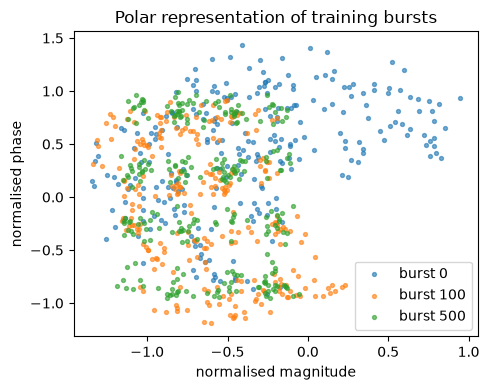

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
for idx in (0, 100, 500):
    mag, phase = ds_train[idx][0]
    ax.scatter(mag, phase, s=8, alpha=0.6, label=f"burst {idx}")
ax.set_xlabel("normalised magnitude")
ax.set_ylabel("normalised phase")
ax.set_title("Polar representation of training bursts")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- Verify synthetic phase range (run after get_data) ---
import numpy as np, matplotlib.pyplot as plt
_ = get_data(iq_imb=False, polar=True, full_range=True)   # populates global ds_train
phs, iq_pts = [], []
for k in range(min(300, len(ds_train))):
    mag, ph = ds_train[k][0].numpy()
    phs.append(ph)
    if k < 5:
        r = mag * 1.5
        iq_pts.append((r*np.cos(ph*2*np.pi), r*np.sin(ph*2*np.pi)))
phs = np.concatenate(phs)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(phs, bins=60, color="#2471a3", alpha=.8)
ax[0].axvline(0, ls="--", c="k"); ax[0].axvline(1, ls="--", c="k")
ax[0].set_title(f"phase distribution  (range [{phs.min():.2f}, {phs.max():.2f}])")
ax[0].set_xlabel("normalised phase")
for I, Q in iq_pts:
    ax[1].scatter(I, Q, s=6, alpha=.5)
ax[1].axhline(0, c="k", lw=.6); ax[1].axvline(0, c="k", lw=.6)
ax[1].set_title("received samples (I/Q)"); ax[1].set_xlabel("I"); ax[1].set_ylabel("Q"); ax[1].set_aspect("equal")
plt.tight_layout(); plt.show()

## 3. The DCI disentanglement metric

We fit a gradient-boosted regressor from the learned latents to each
ground-truth factor and read off the **feature-importance matrix**
$R \in \mathbb{R}^{(\text{latents} \times \text{factors})}$, where $R_{ij}$ is the
importance of latent $i$ for predicting factor $j$.

* **Disentanglement** &mdash; for each latent, how *concentrated* its importance is
  across factors (1 = the latent predicts a single factor).
* **Completeness** &mdash; for each factor, how *concentrated* its importance is
  across latents (1 = the factor is predicted by a single latent).

Both are computed as $1 - \tfrac{H(p)}{H_{\max}}$, the normalised entropy of the
relevant (row / column) importance distribution.


In [ ]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor


def compute_dci(latents, factors):
    """DCI Disentanglement and Completeness scores.

    Args:
        latents: array (N, d) of learned representations.
        factors: array (N, k) of ground-truth generative factors.

    Returns:
        dict with keys "disentanglement" and "completeness" in [0, 1].
    """
    latents = np.asarray(latents)
    factors = np.asarray(factors)
    n_latents = latents.shape[1]
    n_factors = factors.shape[1]

    # Importance[i, j] = importance of latent i for predicting factor j.
    importance = np.zeros((n_latents, n_factors))
    for j in range(n_factors):
        model = GradientBoostingRegressor(n_estimators=100, max_depth=3)
        model.fit(latents, factors[:, j])
        importance[:, j] = model.feature_importances_

    def normalised_concentration(weights, n_bins):
        """1 - normalised entropy of a non-negative weight vector."""
        if weights.sum() <= 0:
            return 0.0
        p = weights / weights.sum()
        entropy = -(p * np.log(p + 1e-12)).sum()
        return 1.0 - entropy / np.log(n_bins)

    # Disentanglement: per-latent concentration across factors.
    disent = np.mean([
        normalised_concentration(importance[i, :], n_factors) for i in range(n_latents)
    ])

    # Completeness: per-factor concentration across latents.
    complete = np.mean([
        normalised_concentration(importance[:, j], n_latents) for j in range(n_factors)
    ])

    return {"disentanglement": float(disent), "completeness": float(complete)}

## 4. Architectures under test

* **PolarMKAN** &mdash; porposed approach. 
* **MKAN** &mdash; the monotonic, polar Kolmogorov&ndash;Arnold autoencoder added in
  this repository (`src/architectures/features_extractors/mkan.py`). The
  monotonic spline parametrisation and the polar masking are designed to align
  individual latents with individual physical factors.
* **KAN-AE (plain)** &mdash; the same KAN autoencoder *without* the monotonic / polar
  constraints, as an ablation.
* **CNN-AE** &mdash; a standard 1-D convolutional autoencoder baseline
  (`src/architectures/features_extractors/cnn.py`).

All models share a **3-dimensional bottleneck** (`hidden_size = 3`) for two
ground-truth factors, and are trained with a pure reconstruction objective.


In [27]:
import torch
from torch import nn

from src.architectures.features_extractors.mkan import Autoencoder as KAN_AE
from src.architectures.features_extractors.cnn import AE_CNN_1D
from src.trainers import AE_Trainer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Each entry is a zero-argument factory returning a fresh model, plus its lr.
configs = [
    {
        'name': 'MKAN',
        'model': lambda: KAN_AE(input_size=512, hidden_size=3, grid_size=8, monotonic=True, polars=False),
        'data_polars': False
    },

    {
        'name': 'PolarMKAN',
        'model': lambda: KAN_AE(input_size=512, hidden_size=3, grid_size=8, monotonic=True, polars=True),
        'data_polars': True
    },

    {
        'name': 'KAN',
        'model': lambda: KAN_AE(input_size=512, hidden_size=3, grid_size=8, monotonic=False, polars=False),
        'data_polars': False
    },
    
   {
       'name': 'CNN AE', 
       'model': lambda:  AE_CNN_1D(input_signal_length=256, features_size=3),
       'data_polars': False
       
   },

    # --- polar-input variants (ablation: isolate the polar representation) ---
    {
        'name': 'Polar KAN',
        'model': lambda: KAN_AE(input_size=512, hidden_size=3, grid_size=8, monotonic=False, polars=False),
        'data_polars': True   # polar input, NO block partition, non-monotonic
    },

    {
        'name': 'Polar CNN',
        'model': lambda: AE_CNN_1D(input_signal_length=256, features_size=3),
        'data_polars': True   # polar input
    },
]

## 5. Training & evaluation protocol

For each architecture we repeat the following `N_RUNS` times and aggregate:

1. Train the autoencoder for `N_EPOCHS` epochs (reconstruction loss only).
2. Extract the bottleneck latents over the training set.
3. Score **disentanglement**, **completeness**, **Spearman correlation** and the
   final **reconstruction MSE**.

> The paper settings are `N_RUNS = 10`, `N_EPOCHS = 120`. On CPU this is slow &mdash;
> lower them for a quick smoke test.


In [28]:
from scipy import stats

N_RUNS = 1
N_EPOCHS = 120
FULL_RANGE = True   # set False to run the confined (left half-plane) control


def reconstruction_mse(model, loader, device):
    """Mean per-element reconstruction MSE over the loader."""
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch, _ in loader:
            batch = batch.to(device)
            _, rec = model(batch)
            b = batch.shape[0]
            total += torch.mean((rec.reshape(b, -1) - batch.reshape(b, -1)) ** 2).item()
            n += 1
    return total / n


def evaluate_architecture(iq_imb, config, lr, n_runs=N_RUNS, n_epochs=N_EPOCHS, device=DEVICE):
    """Train `model_fn` `n_runs` times and collect disentanglement metrics."""
    trainloader, valloader = get_data(iq_imb, config['data_polars'], full_range=FULL_RANGE)
    factors = torch.cat([f for _, f in trainloader]).numpy()
    results = {"disentanglement": [], "completeness": [], "spearman": [], "recon_mse": []}

    for run in range(n_runs):
        torch.manual_seed(run)
        models = nn.ModuleDict({"feature_extractor": config['model']() })
        optimizers = {"main_optimizer": torch.optim.Adam(models.parameters(), lr=lr)}
        trainer = AE_Trainer(models=models, optimizers=optimizers,
                             num_epochs=n_epochs, device=device)

        for _ in range(n_epochs):
            trainer.train_epoch(trainloader)

        features = trainer.get_features(trainloader).numpy()
        dci = compute_dci(features, factors)
        spearman = abs(stats.spearmanr(features.sum(-1), factors.sum(-1)).statistic)
        mse = reconstruction_mse(models['feature_extractor'].to(device), trainloader, device)

        results["disentanglement"].append(dci["disentanglement"])
        results["completeness"].append(dci["completeness"])
        results["spearman"].append(spearman)
        results["recon_mse"].append(mse)

        print(f"  run {run:>2}: D={dci['disentanglement']:.3f}  "
              f"C={dci['completeness']:.3f}  rho={spearman:.3f}  mse={mse:.4f}")

    return results

In [31]:
all_results = {}
for config in configs:
    name = config['name']
    print(f"=== {name} ===")
    all_results[name] = evaluate_architecture(True, config, 0.01)

=== MKAN ===
  run  0: D=0.237  C=0.195  rho=0.635  mse=0.7822
  run  1: D=0.290  C=0.217  rho=0.617  mse=0.7822
  run  2: D=0.210  C=0.186  rho=0.625  mse=0.7822
  run  3: D=0.280  C=0.229  rho=0.616  mse=0.7822
  run  4: D=0.211  C=0.185  rho=0.636  mse=0.7822
  run  5: D=0.230  C=0.186  rho=0.601  mse=0.7822
  run  6: D=0.289  C=0.229  rho=0.625  mse=0.7822
  run  7: D=0.233  C=0.197  rho=0.617  mse=0.7822
  run  8: D=0.273  C=0.214  rho=0.621  mse=0.7822
  run  9: D=0.239  C=0.185  rho=0.630  mse=0.7822
=== PolarMKAN ===
  run  0: D=0.379  C=0.206  rho=0.604  mse=0.0052
  run  1: D=0.392  C=0.216  rho=0.604  mse=0.0052


KeyboardInterrupt: 

## 6. Results summary

Mean &plusmn; 95% confidence interval over the runs. Higher **disentanglement**,
**completeness** and **Spearman** are better; lower **reconstruction MSE** is
better.


In [30]:
import pandas as pd


def mean_ci(values):
    arr = np.asarray(values)
    return arr.mean(), 1.96 * arr.std() / np.sqrt(len(arr))


rows = []
for name, res in all_results.items():
    row = {"architecture": name}
    for metric, values in res.items():
        mean, ci = mean_ci(values)
        row[metric] = f"{mean:.3f} +/- {ci:.3f}"
    rows.append(row)

summary = pd.DataFrame(rows).set_index("architecture")
summary

,disentanglement,completeness,spearman,recon_mse
architecture,,,,
MKAN,0.243 +/- 0.010,0.203 +/- 0.008,0.622 +/- 0.006,0.782 +/- 0.000
PolarMKAN,0.394 +/- 0.023,0.244 +/- 0.033,0.589 +/- 0.020,0.005 +/- 0.000
KAN,0.146 +/- 0.038,0.151 +/- 0.033,0.604 +/- 0.062,0.782 +/- 0.000
CNN AE,0.096 +/- 0.053,0.098 +/- 0.042,0.357 +/- 0.076,0.782 +/- 0.000
